# Testing the signal quality with Alphalens

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import seaborn as sns

from alphalens.tears import (create_summary_tear_sheet,
                             create_full_tear_sheet)

from alphalens.utils import get_clean_factor_and_forward_returns

In [3]:
sns.set_style('whitegrid')

In [4]:
idx = pd.IndexSlice

In [5]:
results_path = Path('results', 'return_predictions')
if not results_path.exists():
    results_path.mkdir(parents=True)

## Evaluating the Cross-Validation Results

In [6]:
lookahead = 1

In [7]:
cv_store = Path(results_path / 'parameter_tuning.h5')

### Get AlphaLens Input

In [8]:
DATA_DIR = Path('/media/n1c0/SanDiskSSD')

Using next available prices.

In [9]:
def get_trade_prices(tickers):
    store = DATA_DIR / 'assets.h5'
    prices = pd.read_hdf(store, 'stooq/jp/tse/stocks/prices')
    return (prices.loc[idx[tickers, '2014': '2019'], 'open']
            .unstack('ticker')
            .sort_index()
            .shift(-1)
            .dropna()
            .tz_localize('UTC'))

Reloading predictions.

In [12]:
best_predictions = pd.read_hdf(results_path / 'predictions.h5', f'test/{lookahead:02}')
best_predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 475776 entries, ('9984.JP', Timestamp('2019-11-29 00:00:00')) to ('3302.JP', Timestamp('2018-01-05 00:00:00'))
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   y_test  475776 non-null  float64
 1   0       475776 non-null  float64
 2   1       475776 non-null  float64
 3   2       472000 non-null  float64
 4   3       472000 non-null  float64
 5   4       475776 non-null  float64
 6   5       475776 non-null  float64
 7   6       472000 non-null  float64
 8   7       475776 non-null  float64
 9   8       472000 non-null  float64
 10  9       472000 non-null  float64
dtypes: float64(11)
memory usage: 42.0+ MB


In [13]:
test_tickers = best_predictions.index.get_level_values('ticker').unique()

In [14]:
trade_prices = get_trade_prices(test_tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1464 entries, 2014-01-06 00:00:00+00:00 to 2019-12-27 00:00:00+00:00
Columns: 944 entries, 9984.JP to 3302.JP
dtypes: float64(944)
memory usage: 10.6 MB


In [15]:
factor = (best_predictions
          .iloc[:, :3]
          .mean(1)
          .tz_localize('UTC', level='date')
          .swaplevel()
          .dropna()
          .reset_index()
          .drop_duplicates()
          .set_index(['date', 'ticker']))

In [16]:
factor_data = get_clean_factor_and_forward_returns(factor=factor,
                                                   prices=trade_prices,
                                                   quantiles=5,
                                                   periods=(1, 5, 10, 21))
factor_data.sort_index().info()

Dropped 4.2% entries from factor data: 4.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 455952 entries, (Timestamp('2017-12-05 00:00:00+0000', tz='UTC'), '1301.JP') to (Timestamp('2019-11-28 00:00:00+0000', tz='UTC'), '9997.JP')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   1D               455952 non-null  float64
 1   5D               455952 non-null  float64
 2   10D              455952 non-null  float64
 3   21D              455952 non-null  float64
 4   factor           455952 non-null  float64
 5   factor_quantile  455952 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 22.7+ MB


### Summary Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.090930,0.008483,-0.008597,0.007455,91287,20.021186
2,-0.029691,0.010470,-0.003716,0.005382,91287,20.021186
3,-0.025428,0.013743,-0.001443,0.005291,90804,19.915254
4,-0.022307,0.017926,0.000866,0.005339,91287,20.021186
5,-0.019717,0.116784,0.006152,0.007681,91287,20.021186


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,54.576,1.148,0.452,0.192
beta,-0.020,-0.027,-0.015,-0.007
Mean Period Wise Return Top Quantile (bps),152.201,28.740,13.925,6.529
Mean Period Wise Return Bottom Quantile (bps),-147.401,-28.580,-14.046,-6.673
Mean Period Wise Spread (bps),299.602,57.327,27.975,13.204


Information Analysis


,1D,5D,10D,21D
IC Mean,0.667,0.279,0.194,0.132
IC Std.,0.091,0.116,0.119,0.116
Risk-Adjusted IC,7.304,2.404,1.636,1.133
t-stat(IC),160.529,52.838,35.950,24.908
p-value(IC),0.000,0.000,0.000,0.000
IC Skew,-1.444,-0.193,-0.152,-0.265
IC Kurtosis,5.694,0.575,0.534,0.771


Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.768,0.787,0.792,0.785
Quantile 2 Mean Turnover,0.787,0.796,0.798,0.793
Quantile 3 Mean Turnover,0.779,0.789,0.793,0.791
Quantile 4 Mean Turnover,0.790,0.792,0.797,0.797
Quantile 5 Mean Turnover,0.770,0.788,0.789,0.785


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.004,-0.009,-0.013,0.004


<Figure size 640x480 with 0 Axes>

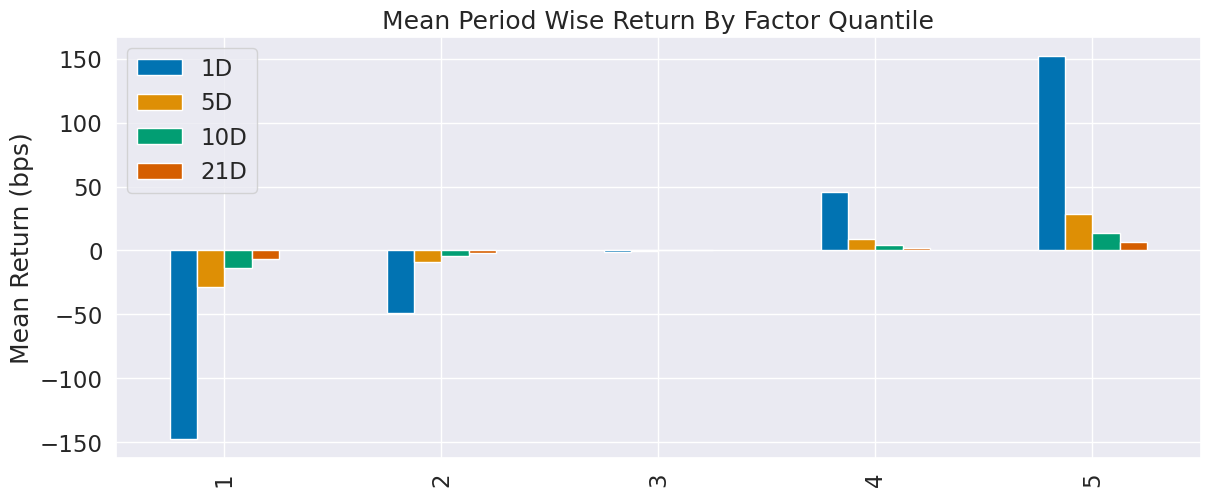

In [17]:
create_summary_tear_sheet(factor_data)

## Evaluating the Out-of-sample predictions

### Prepare Factor Data

In [18]:
t = 1
predictions = pd.read_hdf(results_path / 'predictions.h5',
                          f'test/{t:02}').drop('y_test', axis=1)

In [19]:
predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 475776 entries, ('9984.JP', Timestamp('2019-11-29 00:00:00')) to ('3302.JP', Timestamp('2018-01-05 00:00:00'))
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       475776 non-null  float64
 1   1       475776 non-null  float64
 2   2       472000 non-null  float64
 3   3       472000 non-null  float64
 4   4       475776 non-null  float64
 5   5       475776 non-null  float64
 6   6       472000 non-null  float64
 7   7       475776 non-null  float64
 8   8       472000 non-null  float64
 9   9       472000 non-null  float64
dtypes: float64(10)
memory usage: 38.3+ MB


In [20]:
factor = (predictions.iloc[:, :10]
                   .mean(1)
                   .sort_index().tz_localize('UTC', level='date').swaplevel().dropna())
factor.head()

date                       ticker 
2017-12-05 00:00:00+00:00  1301.JP   -0.001437
2017-12-06 00:00:00+00:00  1301.JP    0.002501
2017-12-07 00:00:00+00:00  1301.JP    0.000414
2017-12-08 00:00:00+00:00  1301.JP    0.000719
2017-12-11 00:00:00+00:00  1301.JP    0.003867
dtype: float64

### Select next available trade prices

Using next available prices.

In [21]:
tickers = factor.index.get_level_values('ticker').unique()
trade_prices = get_trade_prices(tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1464 entries, 2014-01-06 00:00:00+00:00 to 2019-12-27 00:00:00+00:00
Columns: 944 entries, 1301.JP to 9997.JP
dtypes: float64(944)
memory usage: 10.6 MB


### Get AlphaLens Inputs

In [26]:
factor_data = get_clean_factor_and_forward_returns(factor=factor,
                                                   prices=trade_prices,
                                                   quantiles=5,
                                                   periods=(1, 5, 10, 21))
factor_data.sort_index().info()

Dropped 4.2% entries from factor data: 4.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 455952 entries, (Timestamp('2017-12-05 00:00:00+0000', tz='UTC'), '1301.JP') to (Timestamp('2019-11-28 00:00:00+0000', tz='UTC'), '9997.JP')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   1D               455952 non-null  float64
 1   5D               455952 non-null  float64
 2   10D              455952 non-null  float64
 3   21D              455952 non-null  float64
 4   factor           455952 non-null  float64
 5   factor_quantile  455952 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 22.8+ MB


### Summary Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.043361,0.014053,-0.003909,0.006181,91292,20.022283
2,-0.037980,0.014276,-0.002528,0.005635,91288,20.021406
3,-0.037725,0.020661,-0.001721,0.005507,90801,19.914596
4,-0.037495,0.022232,-0.000873,0.005528,91293,20.022502
5,-0.037149,0.030234,0.000586,0.005861,91278,20.019213


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,0.040,0.011,0.004,0.015
beta,0.032,0.023,0.012,0.020
Mean Period Wise Return Top Quantile (bps),2.076,1.090,0.625,0.811
Mean Period Wise Return Bottom Quantile (bps),-2.494,-0.317,-0.193,-0.594
Mean Period Wise Spread (bps),4.570,1.404,0.814,1.400


Information Analysis


,1D,5D,10D,21D
IC Mean,0.007,0.004,0.002,0.009
IC Std.,0.105,0.107,0.106,0.103
Risk-Adjusted IC,0.069,0.038,0.022,0.090
t-stat(IC),1.510,0.843,0.491,1.985
p-value(IC),0.132,0.400,0.624,0.048
IC Skew,0.416,0.204,0.238,0.366
IC Kurtosis,1.188,0.508,0.745,0.822


Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.712,0.758,0.782,0.791
Quantile 2 Mean Turnover,0.773,0.784,0.794,0.798
Quantile 3 Mean Turnover,0.776,0.789,0.798,0.796
Quantile 4 Mean Turnover,0.773,0.786,0.791,0.799
Quantile 5 Mean Turnover,0.703,0.740,0.772,0.795


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.152,0.099,0.039,0.002


<Figure size 640x480 with 0 Axes>

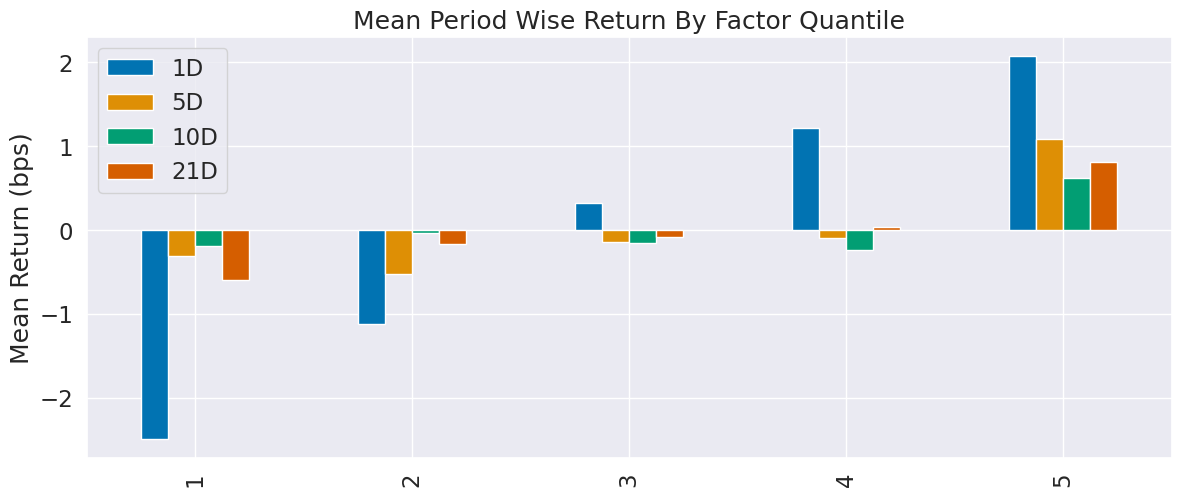

In [27]:
create_summary_tear_sheet(factor_data)